# DenseNet121 Staged Fine-tuning

Model setting:

- Backbone: DenseNet121
- Pretrained weights: ImageNet
- Loss function: Class-weighted CrossEntropyLoss
- Optimizer: AdamW
- Training strategy: staged fine-tuning
- Stage 1: freeze DenseNet feature extractor and train classifier only
- Stage 2: unfreeze all layers and fine-tune with a smaller learning rate
- Stage 1 learning rate: 1e-3
- Stage 2 learning rate: 1e-5
- Batch size: 32
- Best model selection: validation QWK


In [1]:
EXPERIMENT_NAME = "densenet121_staged_focal_gamma15_adamw"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32

STAGE1_EPOCHS = 8
STAGE1_LR = 5e-4
STAGE1_PATIENCE = 4

STAGE2_EPOCHS = 25
STAGE2_LR = 5e-6
STAGE2_PATIENCE = 7

MONITOR_METRIC = "qwk"

print("Experiment:", EXPERIMENT_NAME)

Experiment: densenet121_staged_focal_gamma15_adamw


In [2]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent

elif (current_path / "data").exists() and (current_path / "models").exists():
    PROJECT_ROOT = current_path

else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models folder exists:", (PROJECT_ROOT / "models").exists())
print("densenet.py exists:", (PROJECT_ROOT / "models" / "densenet.py").exists())
print("utils folder exists:", (PROJECT_ROOT / "utils").exists())
print("train_utils.py exists:", (PROJECT_ROOT / "utils" / "train_utils.py").exists())


Current path: D:\760-Group1-main\wanqian
Project root: D:\760-Group1-main
models folder exists: True
densenet.py exists: True
utils folder exists: True
train_utils.py exists: True


In [3]:
import torch
import torch.nn as nn

from models.densenet import get_densenet121, count_trainable_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

# Stage 1: freeze DenseNet feature extractor
for param in model.features.parameters():
    param.requires_grad = False

trainable_params, total_params = count_trainable_parameters(model)

print("Stage 1: classifier-only training")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Device: cpu
Stage 1: classifier-only training
Trainable parameters: 5,125
Total parameters:     6,958,981


In [4]:
# dataloader
from utils.dataset import get_dataloaders, print_dataset_info

SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [5]:
# Focal Loss gamma=1.5 + AdamW

import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction="none",
            weight=self.alpha
        )

        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss


criterion = FocalLoss(gamma=1.5)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE1_LR,
    weight_decay=1e-4
)

print("Loss function: Focal Loss, gamma=1.5")
print("Optimizer: AdamW")

Loss function: Focal Loss, gamma=1.5
Optimizer: AdamW


## create densenet

In [6]:
from utils.train_utils import train_model
import pandas as pd

# =========================
# Stage 1: train classifier only
# =========================

stage1_save_path = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}_stage1.pth"

model, history_stage1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=STAGE1_EPOCHS,
    save_path=stage1_save_path,
    monitor_metric=MONITOR_METRIC,
    patience=STAGE1_PATIENCE,
    min_delta=1e-4,
)

history_stage1["stage"] = "stage1_classifier_only"

print("Stage 1 finished.")
print("Saved Stage 1 model to:", stage1_save_path)


# =========================
# Stage 2: unfreeze all layers and fine-tune
# =========================

for param in model.features.parameters():
    param.requires_grad = True

trainable_params, total_params = count_trainable_parameters(model)

print("Stage 2: full fine-tuning")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=STAGE2_LR,
    weight_decay=1e-4
)

stage2_save_path = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_stage2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=STAGE2_EPOCHS,
    save_path=stage2_save_path,
    monitor_metric=MONITOR_METRIC,
    patience=STAGE2_PATIENCE,
    min_delta=1e-4,
)

history_stage2["stage"] = "stage2_full_finetuning"

# Combine histories
history_stage2["epoch"] = history_stage2["epoch"] + history_stage1["epoch"].max()

history_df = pd.concat(
    [history_stage1, history_stage2],
    ignore_index=True
)

print("Stage 2 finished.")
print("Saved final model to:", stage2_save_path)

history_df.tail()





Epoch 1/8
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 1.0906 | Train Acc: 0.3330 | Train Macro F1: 0.2104 | Train QWK: 0.1305
Val Loss:   1.0134 | Val Acc:   0.3014 | Val Macro F1: 0.1831 | Val QWK:   0.1244 | Val MAE:   1.1438
New best model found at epoch 1.
Best val qwk: 0.1244
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_staged_focal_gamma15_adamw_stage1.pth

Epoch 2/8
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Train Loss: 0.3400 | Train Acc: 0.7568 | Train Macro F1: 0.7258 | Train QWK: 0.8872
Val Loss:   0.4199 | Val Acc:   0.7397 | Val Macro F1: 0.6562 | Val QWK:   0.8424 | Val MAE:   0.3630
No improvement in val qwk. Patience: 4/7

Epoch 25/25
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.3426 | Train Acc: 0.7715 | Train Macro F1: 0.7599 | Train QWK: 0.8847
Val Loss:   0.4021 | Val Acc:   0.7534 | Val Macro F1: 0.6797 | Val QWK:   0.8608 | Val MAE:   0.3356
New best model found at epoch 25.
Best val qwk: 0.8608
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_staged_focal_gamma15_adamw.pth
Stage 2 finished.
Saved final model to: D:\760-Group1-main\outputs\models\densenet121_staged_focal_gamma15_adamw.pth


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate,stage
28,29,0.362048,0.431447,20,0,0.755859,0.727268,0.747100,0.309570,0.883099,...,0.706500,0.363014,0.846072,38,28,10,0.260274,0.191781,0.068493,stage2_full_finetuning
29,30,0.379128,0.422040,20,1,0.760742,0.742091,0.756512,0.322266,0.865888,...,0.706352,0.376712,0.831671,38,27,11,0.260274,0.184932,0.075342,stage2_full_finetuning
30,31,0.369299,0.422234,20,2,0.772461,0.751209,0.765937,0.307617,0.874978,...,0.706547,0.376712,0.831694,38,27,11,0.260274,0.184932,0.075342,stage2_full_finetuning
31,32,0.339965,0.419875,20,3,0.756836,0.725784,0.749665,0.302734,0.887191,...,0.708562,0.363014,0.842377,38,28,10,0.260274,0.191781,0.068493,stage2_full_finetuning
32,33,0.342566,0.402108,20,4,0.771484,0.759917,0.766118,0.295898,0.884749,...,0.721133,0.335616,0.860761,36,27,9,0.246575,0.184932,0.061644,stage2_full_finetuning


In [7]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df.tail()

,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate,stage
28,29,0.362048,0.431447,20,0,0.755859,0.727268,0.747100,0.309570,0.883099,...,0.706500,0.363014,0.846072,38,28,10,0.260274,0.191781,0.068493,stage2_full_finetuning
29,30,0.379128,0.422040,20,1,0.760742,0.742091,0.756512,0.322266,0.865888,...,0.706352,0.376712,0.831671,38,27,11,0.260274,0.184932,0.075342,stage2_full_finetuning
30,31,0.369299,0.422234,20,2,0.772461,0.751209,0.765937,0.307617,0.874978,...,0.706547,0.376712,0.831694,38,27,11,0.260274,0.184932,0.075342,stage2_full_finetuning
31,32,0.339965,0.419875,20,3,0.756836,0.725784,0.749665,0.302734,0.887191,...,0.708562,0.363014,0.842377,38,28,10,0.260274,0.191781,0.068493,stage2_full_finetuning
32,33,0.342566,0.402108,20,4,0.771484,0.759917,0.766118,0.295898,0.884749,...,0.721133,0.335616,0.860761,36,27,9,0.246575,0.184932,0.061644,stage2_full_finetuning


## best epoch 

In [8]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])



Best epoch based on validation QWK:
epoch                        33
val_loss               0.402108
val_accuracy           0.753425
val_macro_f1           0.679716
val_weighted_f1        0.721133
val_mae                0.335616
val_qwk                0.860761
val_adjacent_errors          27
val_distant_errors            9
Name: 32, dtype: object


## train model

save history

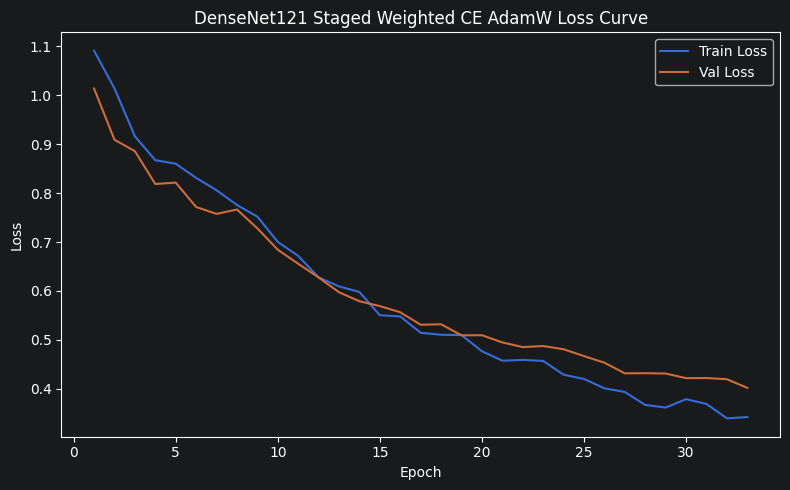

Saved figure to: D:\760-Group1-main\outputs\figures\densenet121_staged_focal_gamma15_adamw_loss.png


In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Staged Weighted CE AdamW Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_loss.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [10]:
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics
# train set
val_loss, val_metrics, val_true, val_pred = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device,
)

print_metrics(val_metrics, title="Validation Metrics")


Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Validation Metrics
accuracy: 0.7534
macro_f1: 0.6797
weighted_f1: 0.7211
mae: 0.3356
qwk: 0.8608
total_errors: 36
adjacent_errors: 27
distant_errors: 9
total_error_rate: 0.2466
adjacent_error_rate: 0.1849
distant_error_rate: 0.0616


In [11]:
from utils.metrics import get_classification_report


# test set
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print_metrics(test_metrics, title="Test Metrics")


#classification report 
report = get_classification_report(
    y_true=test_true,
    y_pred=test_pred,
    class_names=class_names,
)

print(report)


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Test Metrics
accuracy: 0.7007
macro_f1: 0.6616
weighted_f1: 0.6862
mae: 0.4116
qwk: 0.8207
total_errors: 88
adjacent_errors: 64
distant_errors: 24
total_error_rate: 0.2993
adjacent_error_rate: 0.2177
distant_error_rate: 0.0816
              precision    recall  f1-score   support

     0Normal       0.72      0.81      0.76        91
   1Doubtful       0.63      0.76      0.69        88
       2Mild       0.47      0.21      0.29        38
   3Moderate       0.80      0.69      0.74        35
     4Severe       0.87      0.79      0.82        42

    accuracy                           0.70       294
   macro avg       0.70      0.65      0.66       294
weighted avg       0.69      0.70      0.69       294



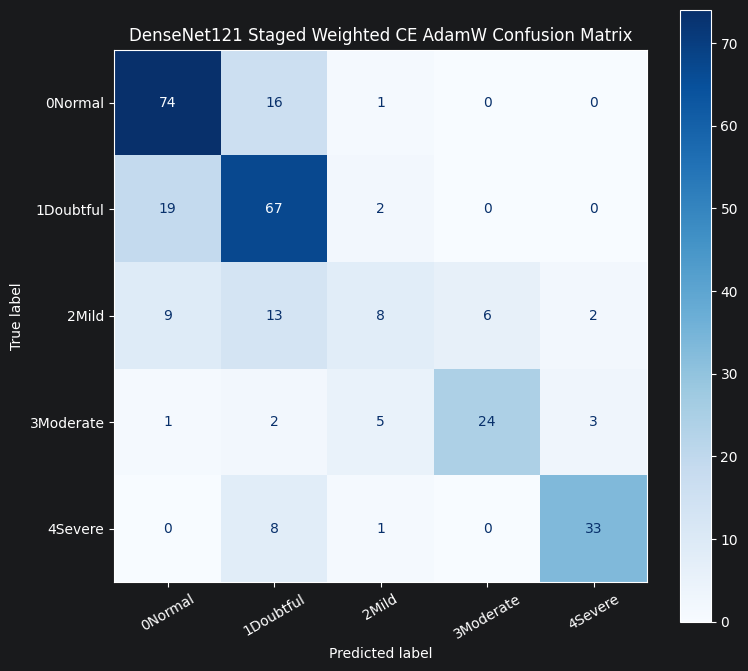

Saved figure to: D:\760-Group1-main\outputs\figures\densenet121_staged_focal_gamma15_adamw_confusion_matrix.png


In [12]:
# Confusion matrix
from utils.metrics import get_confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 Staged Weighted CE AdamW Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_confusion_matrix.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)
